Question 1: Predict loan approval on loan_approval_dataset.csv file (in GitHub repo).
- (a) Use Logistic Regression
- (b) Then try using Naive Bayes
- (c) Perform encoding and scaling as appropriate
- (d) Display confusion matrix and customized classification report
- (e) Compare the results and check which one has a better accuracy

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [5]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [6]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### Preprocessing 

#### Converting categorical data into numerical
- education,	self_employed,	loan_status

In [7]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])

In [8]:
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [9]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


#### Split the dataset into training and testing

In [10]:
X = df.iloc[:,1:12]
y = df.iloc[:,-1]

In [11]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [12]:
y.head()

0    0
1    1
2    1
3    1
4    1
Name: loan_status, dtype: int64

#### Scaling 

In [13]:
scaler = MinMaxScaler()
X_scaled_array = scaler.fit_transform(X)

In [14]:
X_scaled_df = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

#### Split the dataset into training and testing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)

      no_of_dependents  education  self_employed  income_annum  loan_amount  \
1675               1.0        1.0            0.0      0.793814     0.755102   
1164               0.0        1.0            1.0      0.969072     0.859694   
192                0.2        0.0            0.0      0.061856     0.066327   
910                0.4        0.0            1.0      0.484536     0.326531   
567                1.0        0.0            1.0      0.288660     0.275510   
...                ...        ...            ...           ...          ...   
3444               0.0        0.0            1.0      0.113402     0.112245   
466                1.0        1.0            1.0      0.030928     0.038265   
3092               0.8        1.0            1.0      0.865979     0.517857   
3772               0.4        1.0            1.0      0.701031     0.538265   
860                0.8        0.0            0.0      0.618557     0.433673   

      loan_term  cibil_score  residential_assets_va

#### Train the model

In [16]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter = 600)
lr_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,600
,multi_class,'deprecated'


In [17]:
ypred_lr = lr_model.predict(X_test)

In [18]:
from sklearn.naive_bayes import GaussianNB
naiveBayes_model = GaussianNB()
naiveBayes_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [19]:
ypred_naiveBayes = naiveBayes_model.predict(X_test)

#### Evaluate the model

In [20]:
lr_accuracy_score = accuracy_score(y_test, ypred_lr)
naiveBayes_accuracy_score = accuracy_score(y_test, ypred_naiveBayes)
print(lr_accuracy_score)
print(naiveBayes_accuracy_score)

0.9121779859484778
0.936768149882904


In [21]:
lr_classification_report = classification_report(y_test, ypred_lr,target_names=['Rejected','Approved'])
naiveBayes_classification_report = classification_report(y_test, ypred_naiveBayes,target_names=['Rejected','Approved'])
print(lr_classification_report)
print(naiveBayes_classification_report)


              precision    recall  f1-score   support

    Rejected       0.93      0.93      0.93       536
    Approved       0.89      0.87      0.88       318

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854

              precision    recall  f1-score   support

    Rejected       0.96      0.94      0.95       536
    Approved       0.90      0.94      0.92       318

    accuracy                           0.94       854
   macro avg       0.93      0.94      0.93       854
weighted avg       0.94      0.94      0.94       854



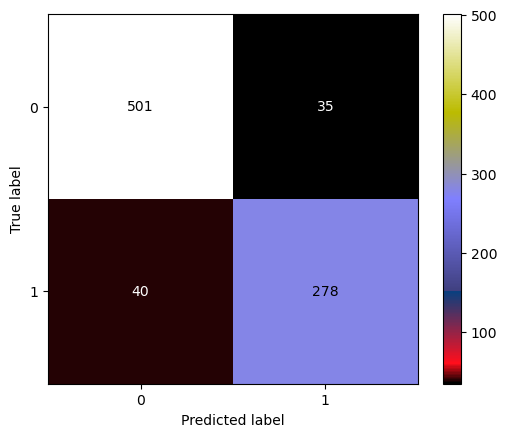

In [22]:
ConfusionMatrixDisplay(confusion_matrix(y_test,ypred_lr)).plot(cmap='gist_stern')

In [48]:
y_test_cm = list(y_test)
y_pred_cm = list(ypred_lr)
tp = 0
tn = 0
fp = 0
fn = 0
for i in range(len(y_test_cm)):
    if y_test_cm[i] == y_pred_cm[i]:
        if y_test_cm[i] == 0:
            tn+=1
        else:
            tp+=1
    else:
        if y_pred_cm[i]==1 and y_test_cm[i]==0:
            fp+=1
        else:
            fn+=1
print("true +ve", tp)
print("true -ve", tn)
print("flase +ve", fp)
print("false -ve", fn)

true +ve 278
true -ve 501
flase +ve 35
false -ve 40


#### For Logistic regression
- Show the top 10 customers most likely to get loan
- Show the bottom 10 customers least likely to get loan

In [23]:
probabilities = lr_model.predict_proba(X_test)[:, 1]
print(probabilities)

[9.49595308e-01 1.81246790e-01 9.20590074e-01 9.55519364e-02
 2.13602017e-02 3.96764535e-02 2.97827823e-02 6.02473804e-01
 2.68926570e-01 7.17290079e-01 4.33382892e-01 1.52482875e-02
 2.27525968e-02 9.01130134e-01 9.11883795e-01 5.40407888e-02
 3.74285553e-02 3.25239970e-01 9.46648743e-01 8.57566840e-01
 2.28304048e-01 9.64071299e-01 8.44202852e-01 8.39206690e-01
 1.02700336e-02 4.31806522e-02 2.93092528e-03 2.20492296e-01
 7.04183635e-03 8.31261886e-01 1.46891323e-01 9.48482395e-01
 3.35108671e-01 2.17848441e-01 9.91527641e-01 9.05326702e-01
 1.71404257e-01 1.54748556e-01 1.16898048e-03 9.74999603e-01
 6.01332025e-01 1.65013094e-01 8.73391945e-04 5.31193356e-04
 6.51318751e-01 7.37232443e-02 2.70684548e-03 4.13608222e-02
 1.06549873e-03 9.31792933e-01 1.29187690e-02 5.62375972e-01
 5.19335962e-01 1.43158856e-03 1.87714254e-02 1.51549348e-02
 1.06751822e-01 1.18923172e-03 4.22401896e-01 6.51676141e-02
 3.75704372e-03 9.57241645e-03 9.49014121e-01 9.77214951e-01
 9.67634021e-01 2.228774

In [25]:
results_df = df.loc[X_test.index].copy()
results_df['Loan_Probability'] = probabilities
results_df_sorted = results_df.sort_values(by='Loan_Probability', ascending=False)

In [26]:
top_10_likely = results_df_sorted.head(10)

print("--- TOP 10 CUSTOMERS MOST LIKELY TO GET A LOAN ---")
print(top_10_likely[['Loan_Probability']])

--- TOP 10 CUSTOMERS MOST LIKELY TO GET A LOAN ---
      Loan_Probability
4193          0.995619
1502          0.995407
1056          0.994920
803           0.994730
263           0.994401
3107          0.993692
12            0.993394
354           0.993322
494           0.993008
670           0.992439


In [28]:
bottom_10_unlikely = results_df_sorted.tail(10)

print("\n--- BOTTOM 10 CUSTOMERS LEAST LIKELY TO GET A LOAN ---")
print(bottom_10_unlikely[['Loan_Probability']])


--- BOTTOM 10 CUSTOMERS LEAST LIKELY TO GET A LOAN ---
      Loan_Probability
256           0.000387
1513          0.000381
1738          0.000377
2857          0.000351
1029          0.000282
3621          0.000276
576           0.000267
1666          0.000262
3925          0.000175
2755          0.000154


- (g) Find records where predictions differ between LR nd NB and display those records - Analyze why the predictions differ



array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,

In [34]:
# 1. Create a mask where predictions do not match
mismatch_mask = (ypred_lr != ypred_naiveBayes)
print(type(mismatch_mask))
# 2. Extract the conflicting records from your test set
mismatch_records = X_test[mismatch_mask].copy()

# 3. Add the predictions to the dataframe for easy comparison
mismatch_records['Pred_LR'] = ypred_lr[mismatch_mask]
mismatch_records['Pred_NB'] = ypred_naiveBayes[mismatch_mask]

# 4. Display the records
print(f"Total misaligned predictions: {len(mismatch_records)}")
display(mismatch_records.head(10)) # Shows the first 10 conflicts

<class 'numpy.ndarray'>
Total misaligned predictions: 43


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,Pred_LR,Pred_NB
296,1.0,1.0,1.0,0.865979,0.729592,0.333333,0.360000,0.342466,0.092784,0.768638,0.462585,0,1
3839,0.4,1.0,1.0,0.505155,0.420918,0.000000,0.340000,0.222603,0.139175,0.431877,0.299320,0,1
120,1.0,0.0,0.0,0.072165,0.051020,0.777778,0.408333,0.006849,0.010309,0.061697,0.054422,1,0
315,0.8,0.0,0.0,0.432990,0.364796,0.111111,0.331667,0.047945,0.335052,0.406170,0.387755,0,1
3199,0.0,0.0,0.0,0.298969,0.275510,0.333333,0.340000,0.123288,0.237113,0.285347,0.122449,0,1
1268,0.6,0.0,1.0,0.206186,0.127551,0.000000,0.343333,0.058219,0.087629,0.141388,0.190476,0,1
3340,0.8,0.0,1.0,0.432990,0.410714,0.222222,0.355000,0.188356,0.386598,0.329049,0.387755,0,1
179,1.0,0.0,0.0,0.371134,0.346939,0.555556,0.390000,0.164384,0.149485,0.203085,0.190476,0,1
843,0.0,1.0,0.0,0.175258,0.158163,0.444444,0.371667,0.085616,0.056701,0.151671,0.074830,0,1
2249,0.2,0.0,0.0,0.701031,0.528061,1.000000,0.423333,0.582192,0.340206,0.367609,0.380952,1,0


## Q.3 Confusion Matrix
Question 3: 
(1) Create confusion matrix
| Patient_ID | Actual_Result | Predicted_Result |
| ---------- | ------------- | ---------------- |
| P1         | Disease       | Disease          |
| P2         | Disease       | Disease          |
| P3         | Disease       | No Disease       |
| P4         | Disease       | Disease          |
| P5         | Disease       | No Disease       |
| P6         | Disease       | Disease          |
| P7         | No Disease    | No Disease       |
| P8         | No Disease    | Disease          |
| P9         | No Disease    | No Disease       |
| P10        | No Disease    | No Disease       |
| P11        | No Disease    | Disease          |
| P12        | No Disease    | No Disease       |

In [36]:
import pandas as pd
data = [
    {"Patient_ID": "P1",  "Actual_Result": "Disease",    "Predicted_Result": "Disease"},
    {"Patient_ID": "P2",  "Actual_Result": "Disease",    "Predicted_Result": "Disease"},
    {"Patient_ID": "P3",  "Actual_Result": "Disease",    "Predicted_Result": "No Disease"},
    {"Patient_ID": "P4",  "Actual_Result": "Disease",    "Predicted_Result": "Disease"},
    {"Patient_ID": "P5",  "Actual_Result": "Disease",    "Predicted_Result": "No Disease"},
    {"Patient_ID": "P6",  "Actual_Result": "Disease",    "Predicted_Result": "Disease"},
    {"Patient_ID": "P7",  "Actual_Result": "No Disease", "Predicted_Result": "No Disease"},
    {"Patient_ID": "P8",  "Actual_Result": "No Disease", "Predicted_Result": "Disease"},
    {"Patient_ID": "P9",  "Actual_Result": "No Disease", "Predicted_Result": "No Disease"},
    {"Patient_ID": "P10", "Actual_Result": "No Disease", "Predicted_Result": "No Disease"},
    {"Patient_ID": "P11", "Actual_Result": "No Disease", "Predicted_Result": "Disease"},
    {"Patient_ID": "P12", "Actual_Result": "No Disease", "Predicted_Result": "No Disease"}
]

df1 = pd.DataFrame(data)

print(df1)

   Patient_ID Actual_Result Predicted_Result
0          P1       Disease          Disease
1          P2       Disease          Disease
2          P3       Disease       No Disease
3          P4       Disease          Disease
4          P5       Disease       No Disease
5          P6       Disease          Disease
6          P7    No Disease       No Disease
7          P8    No Disease          Disease
8          P9    No Disease       No Disease
9         P10    No Disease       No Disease
10        P11    No Disease          Disease
11        P12    No Disease       No Disease


In [37]:
d = {
    'Disease' :1,
    'No Disease':0
}
df1['Actual_Result'] = df1['Actual_Result'].map(d)
df1['Predicted_Result'] = df1['Predicted_Result'].map(d)
df1

,Patient_ID,Actual_Result,Predicted_Result
0,P1,1,1
1,P2,1,1
2,P3,1,0
3,P4,1,1
4,P5,1,0
5,P6,1,1
6,P7,0,0
7,P8,0,1
8,P9,0,0
9,P10,0,0


In [39]:
ypred_1 = df['Predicted_Result']
y_test_1 = df['Actual_Result']
cm_1 = confusion_matrix(y_test_1,ypred_1)
print(cm_1)

[[4 2]
 [2 4]]


## Q.3.2 Confusion Matrix
(2) Use the following data
- What is the positive class?
- Identify TP, TN, FP, FN.
- Which error is more dangerous?

| Passenger | Actual Status                | Scanner Result |
| --------- | ---------------------------- | -------------- |
| A         | Carrying prohibited item     | Alarm          |
| B         | Not carrying prohibited item | Alarm          |
| C         | Not carrying prohibited item | No Alarm       |
| D         | Carrying prohibited item     | No Alarm       |
| E         | Carrying prohibited item     | Alarm          |

- What is the positive class?
  + Ans: Alarm 
- Identify TP, TN, FP, FN.    
  + **Ans:**  TP = 2   TN = 1    FP = 1 (predict: Alarm, Actual: Not Carrying)    FN = 1 (predict: No Alarm, Actual: Carrying Prohibited item)
- Which error is more dangerous?
  + Ans: Type-I Error

In [41]:
import pandas as pd

# 1. Define the data as a list of dictionaries
passenger_data = [
    {"Passenger": "A", "Actual Status": "Carrying prohibited item", "Scanner Result": "Alarm"},
    {"Passenger": "B", "Actual Status": "Not carrying prohibited item", "Scanner Result": "Alarm"},
    {"Passenger": "C", "Actual Status": "Not carrying prohibited item", "Scanner Result": "No Alarm"},
    {"Passenger": "D", "Actual Status": "Carrying prohibited item", "Scanner Result": "No Alarm"},
    {"Passenger": "E", "Actual Status": "Carrying prohibited item", "Scanner Result": "Alarm"}
]

# 2. Create the DataFrame
df = pd.DataFrame(passenger_data)

# 3. View the DataFrame
print(df)

  Passenger                 Actual Status Scanner Result
0         A      Carrying prohibited item          Alarm
1         B  Not carrying prohibited item          Alarm
2         C  Not carrying prohibited item       No Alarm
3         D      Carrying prohibited item       No Alarm
4         E      Carrying prohibited item          Alarm


## Q.3.3 
| Email | Actual Spam | Predicted Spam |
| ----- | ----------- | -------------- |
| E1    | Yes         | Yes            |
| E2    | No          | No             |
| E3    | Yes         | No             |
| E4    | No          | No             |
| E5    | Yes         | Yes            |

 Find accuracy without creating a confusion matrix

 + Ans:
   - TP   = 2
   - TN   = 2
   - FP   = 0
   - FN   = 1

Accuracy = (TP + TN) / (TP+TN+FP+FN) = 4/5 = 0.80

(4) A cancer screening system produced:
- 5 False Positives
- 2 False Negatives
<br>Which type of error is more dangerous in this application and why?

